# Multispectral Classification

> Tutorial multispectral classification


In [ ]:
#| default_exp tutorial_multispectral_b

### Setup imports

In [ ]:
from bonsai.data import *
from bonsai.transforms import *
from bonsai.utils import *
from bonsai.losses import CrossEntropyLossFlat
from bonsai.metrics import *
from bonsai.datasets import download_file
from bonsai.io import *
from bonsai.engines import *
from bonsai.inference import *

from fastai.vision.all import accuracy, OptimWrapper
from torch.optim import Adam

import os
import pandas as pd


In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
device = get_device()
print(device)

cuda


In [ ]:
set_determinism(0)

---

In [ ]:
data_folder = '../_data/rxrx1_subset_monai/'
# csv_file = os.path.join(data_folder, 'metadata.csv')

# data = pd.read_csv(csv_file)
# train_data = split_dataframe(
#     data,
#     return_single=True,
#     split_column="dataset",
#     filter_mask=data["dataset"] == "train",                                                                                                                                                                                                                                                                                   
#     overwrite=True,
# )

In [ ]:
from bonsai.transforms import mt

In [ ]:
channels = ['channel 1', 'channel 2', 'channel 3', 'channel 4', 'channel 5', 'channel 6']

transforms_train = [
        LoadImaged(keys=channels, image_only=True),
        mt.EnsureChannelFirstd(keys=channels),
        mt.ScaleIntensityRangePercentilesd(
            keys=channels, lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        mt.ConcatItemsd(keys=channels, name="image", dim=0),
        mt.EnsureTyped(keys=["image", "label"]),
        mt.RandRotate90d(keys=channels, prob=0.75),
        mt.RandFlipd(keys=channels, spatial_axis=[0, 1], prob=0.5),
        mt.RandZoomd(keys=channels, min_zoom=0.9, max_zoom=1.1, prob=0.5),
    ]

# transforms_train = [
#         LoadImaged(keys=channels, image_only=True),
#         EnsureChannelFirstd(keys=channels),
#         ScaleIntensityRangePercentilesd(
#             keys=channels, lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
#         ),
#         ConcatItemsd(keys=channels, name="image", dim=0),
#         EnsureTyped(keys=["image", "label"], track_meta=False),
#         RandRotate90d(keys=channels, prob=0.75),
#         RandFlipd(keys=channels, spatial_axis=[0, 1], prob=0.5),n 
#         RandZoomd(keys=channels, min_zoom=0.9, max_zoom=1.1, prob=0.5),
#     ]

# transforms_val = [
#         LoadImaged(keys=channels, image_only=True),
#         EnsureChannelFirstd(keys=channels),
#         ScaleIntensityRangePercentilesd(
#             keys=channels, lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
#         ),
#         ConcatItemsd(keys=channels, name="image", dim=0),
#     ]


In [ ]:
colmap = {'channel 1': 'channel 1', 'channel 2': 'channel 2', 'channel 3': 'channel 3', 'channel 4': 'channel 4', 'channel 5': 'channel 5', 'channel 6': 'channel 6' }

In [ ]:
data_ops = {
    'x_keys': "image",
    'y_keys': "label",
    'x_class': None,
    'y_class': None,
    'get_items': colmap,
    'transforms': transforms_train,
    # 'val_transforms': transforms_val,
    'vocab':  ['HEPG2', 'HUVEC', 'RPE', 'U2OS'],
    'seed': 42, 
    'batch_size': 8,
    'val_batch_size': 32,
    'num_workers': 10,
    'show_summary': True,
}

data = BioDataLoaders.create(
    data_folder + 'train.csv',
    dataset='cache',
    **data_ops,
    )

Loading dataset: 100%|██████████| 200/200 [00:03<00:00, 55.40it/s]



Train DataLoader
----------------
Dataset size : 800
Batch size   : 8
Batches      : 100
Classes      : ['HEPG2', 'HUVEC', 'RPE', 'U2OS']

Batch structure:
  [0] shape=(8, 6, 512, 512) dtype=torch.float32 ~48.00 MB
  [1] shape=(8,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 48.00 MB

Valid DataLoader
----------------
Dataset size : 200
Batch size   : 32
Batches      : 7
Classes      : ['HEPG2', 'HUVEC', 'RPE', 'U2OS']

Batch structure:
  [0] shape=(32, 6, 512, 512) dtype=torch.float32 ~192.00 MB
  [1] shape=(32,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 192.00 MB


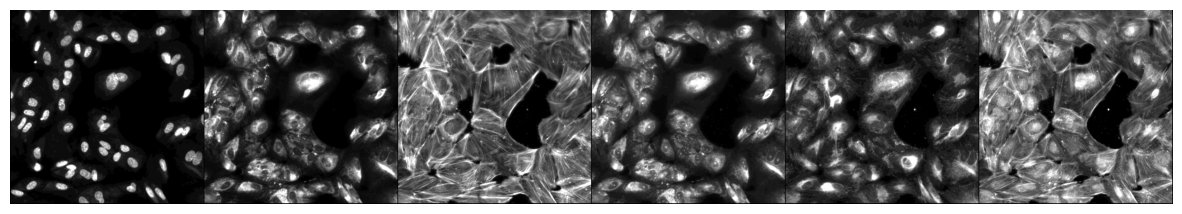

In [ ]:
from bonsai.visualize import show_mosaic
show_mosaic(data.do_item(100)[0])

---

In [ ]:
import torch 
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
from monai.networks.nets import DenseNet169

model = DenseNet169(spatial_dims=2, in_channels=6, out_channels=len(data.vocab), pretrained=True)

In [ ]:
metrics = [accuracy]
optimizer = OptimWrapper(opt=Adam(model.parameters(), 1e-5))
loss_fn=CrossEntropyLossFlat()

trainer = fastTrainer(data, model, loss_fn=loss_fn, metrics=metrics, show_summary=False, lr=1e-5, show_graph=True, optimizer=optimizer)

epoch,train_loss,valid_loss,accuracy,time
0,0.895060,0.485068,0.940000,00:16


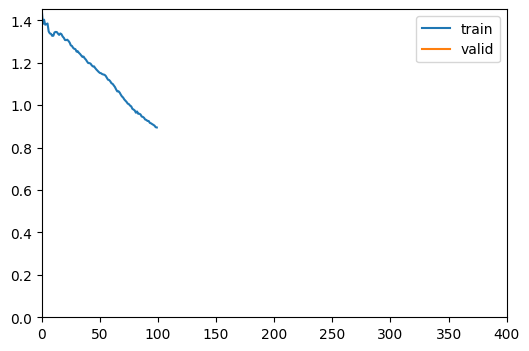

KeyboardInterrupt: 

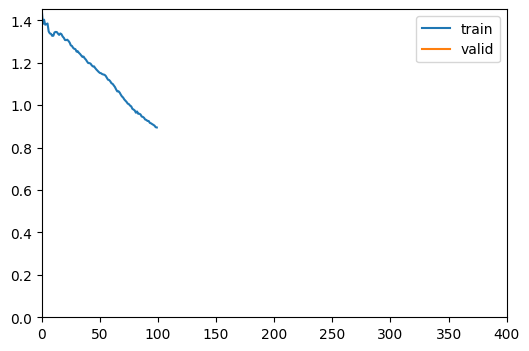

In [ ]:
trainer.fit(4)

In [ ]:
torch.cuda.max_memory_allocated() / 1024**2